# Pizza-Bot - Partie 4 : superviser la buse à mozzarella

La buse doit déposer 100 g de mozzarella par pizza, et chaque dose est pesée. L'atelier a fourni
50 pesées de calibration, réalisées sur une buse en bon état. En production, les pesées arrivent
une à une : il faut décider à chaque fois si la buse fonctionne normalement, et arrêter la
machine quand elle dérive.

Règles du projet : Python de base, aucun import. Seule la cellule de tracé utilise matplotlib,
et uniquement pour visualiser.

## Étape 4.1 : estimer le comportement normal

In [ ]:
historique_calibration = [
    102.5, 102.1, 96.9, 101.0, 98.9, 97.5, 100.3, 101.3, 104.1, 99.5,
    102.4, 93.2, 99.3, 99.9, 98.8, 101.9, 99.5, 101.9, 102.0, 98.0,
    99.6, 99.8, 99.6, 98.3, 98.4, 100.9, 98.2, 98.9, 101.6, 101.4,
    100.0, 97.6, 96.0, 100.2, 99.9, 101.9, 101.8, 99.1, 99.6, 100.0,
    100.2, 100.9, 102.7, 100.9, 100.6, 99.5, 98.5, 98.6, 98.7, 100.1,
]

def moyenne(valeurs):
    return sum(valeurs) / len(valeurs)

def ecart_type_estime(valeurs):
    """Écart-type estimé à partir d'un échantillon : division par N - 1."""
    m = moyenne(valeurs)
    total = 0
    for v in valeurs:
        total = total + (v - m) ** 2
    return (total / (len(valeurs) - 1)) ** 0.5

mu = moyenne(historique_calibration)
sigma = ecart_type_estime(historique_calibration)
print(f"mu = {mu:.2f} g   sigma = {sigma:.3f} g")
print(f"intervalle de tolérance : [{mu - 2 * sigma:.2f} ; {mu + 2 * sigma:.2f}]")

# --- Vérification : ne rien modifier sous cette ligne ---
assert abs(ecart_type_estime([2, 4, 6]) - 2) < 1e-9, "écarts -2, 0, 2 ; somme des carrés 8 ; divisée par N - 1 = 2 ; racine : 2"
assert ecart_type_estime([7, 7, 7, 7]) == 0
print("Écart-type validé")

mu = 99.89 g   sigma = 1.901 g
intervalle de tolérance : [96.09 ; 103.69]
Écart-type validé


**Lecture du résultat.** La buse dépose en moyenne 99,89 g, tout près des 100 g visés, avec
un écart-type de 1,901 g. L'intervalle de tolérance à deux écarts-types va de 96,09 à 103,69 g :
c'est la zone dans laquelle tombent les pesées d'une buse qui fonctionne normalement.

## Étape 4.2 : l'intervalle et ses fausses alertes

In [ ]:
historique_calibration = [
    102.5, 102.1, 96.9, 101.0, 98.9, 97.5, 100.3, 101.3, 104.1, 99.5,
    102.4, 93.2, 99.3, 99.9, 98.8, 101.9, 99.5, 101.9, 102.0, 98.0,
    99.6, 99.8, 99.6, 98.3, 98.4, 100.9, 98.2, 98.9, 101.6, 101.4,
    100.0, 97.6, 96.0, 100.2, 99.9, 101.9, 101.8, 99.1, 99.6, 100.0,
    100.2, 100.9, 102.7, 100.9, 100.6, 99.5, 98.5, 98.6, 98.7, 100.1,
]
# Moyenne et écart-type obtenus à l'étape 4.1.
MU = 99.888
SIGMA = 1.9007771743074244

def z_score(valeur, mu, sigma):
    return (valeur - mu) / sigma

def est_anomalie(valeur, mu, sigma, k=2):
    """True si la valeur sort de [mu - k·sigma ; mu + k·sigma]. Une valeur sur une borne n'en sort pas."""
    return abs(z_score(valeur, mu, sigma)) > k

# La liste des pesées de l'historique qui sont des anomalies.
hors = []
for pesee in historique_calibration:
    if est_anomalie(pesee, MU, SIGMA):
        hors.append(pesee)

print(f"{len(hors)} pesées sur {len(historique_calibration)} hors de l'intervalle : {hors}")

# --- Vérification : ne rien modifier sous cette ligne ---
assert z_score(106, 100, 2) == 3 and z_score(96, 100, 2) == -2
assert est_anomalie(104, 100, 2) is False, "104 est pile sur la borne haute : pas une anomalie"
assert est_anomalie(104.1, 100, 2) is True and est_anomalie(95.9, 100, 2) is True
assert est_anomalie(105, 100, 2, k=3) is False, "à 3 sigmas, la tolérance va jusqu'à 106"
print("Anomalies validées")

3 pesées sur 50 hors de l'intervalle : [104.1, 93.2, 96.0]
Anomalies validées


**Lecture du résultat.** Trois pesées sur cinquante sortent de l'intervalle, alors que la
buse était saine : 104,1 g, 93,2 g et 96,0 g. Ce n'est pas surprenant, puisqu'un seuil à deux
écarts-types laisse environ 4,5 % des pesées au-dehors, soit deux à trois sur cinquante. Ces
trois pesées sont donc des fausses alertes, pas des pannes.

## Étape 4.3 : la boucle temps réel, avec persistance

In [ ]:
flux_temps_reel = [
    100.4, 99.1, 101.7, 98.6, 100.9, 106.8, 99.8, 100.3, 97.9, 101.2,
    92.4, 100.6, 99.4, 102.3, 100.1, 98.8, 103.2, 104.1, 104.9, 105.6,
    106.3,
]
# Moyenne et écart-type obtenus à l'étape 4.1.
MU = 99.888
SIGMA = 1.9007771743074244
PERSISTANCE = 3

def z_score(valeur, mu, sigma):
    return (valeur - mu) / sigma

def est_anomalie(valeur, mu, sigma, k=2):
    return abs(z_score(valeur, mu, sigma)) > k

def surveiller(flux, mu, sigma, k=2, persistance=PERSISTANCE):
    """Renvoie (alertes, indice_arret) ; indice_arret vaut None si la machine n'a pas été arrêtée."""
    alertes = []
    consecutives = 0

    for indice, valeur in enumerate(flux):
        z = z_score(valeur, mu, sigma)
        if est_anomalie(valeur, mu, sigma, k):
            alertes.append((indice, valeur))
            consecutives = consecutives + 1
            print(f"[ALERTE] pesée {indice:2} : {valeur:6.1f} g   z = {z:+.2f}")
            if consecutives == persistance:
                print(f"[ARRÊT ] {persistance} anomalies consécutives : la machine est arrêtée")
                return (alertes, indice)
        else:
            # Une pesée normale remet le compteur à zéro : un pic isolé ne doit pas s'accumuler.
            consecutives = 0
            print(f"[OK    ] pesée {indice:2} : {valeur:6.1f} g   z = {z:+.2f}")

    return (alertes, None)

alertes, arret = surveiller(flux_temps_reel, MU, SIGMA)
print(f"\n{len(alertes)} alertes, arrêt à la pesée {arret}")

# --- Vérification : ne rien modifier sous cette ligne ---
print("\nVérification sur un flux d'essai :")
essai = [100, 105, 100, 105, 105, 105, 100]
assert surveiller(essai, 100, 2) == ([(1, 105), (3, 105), (4, 105), (5, 105)], 5), \
    "alerte en 1, compteur remis à zéro en 2, puis trois anomalies de suite : arrêt en 5, la pesée 6 n'est pas traitée"
assert surveiller([105, 100, 105, 100], 100, 2) == ([(0, 105), (2, 105)], None), "des pics isolés n'arrêtent pas la machine"
assert surveiller([100, 100], 100, 2) == ([], None)
print("Surveillance validée")

[OK    ] pesée  0 :  100.4 g   z = +0.27
[OK    ] pesée  1 :   99.1 g   z = -0.41
[OK    ] pesée  2 :  101.7 g   z = +0.95
[OK    ] pesée  3 :   98.6 g   z = -0.68
[OK    ] pesée  4 :  100.9 g   z = +0.53
[ALERTE] pesée  5 :  106.8 g   z = +3.64
[OK    ] pesée  6 :   99.8 g   z = -0.05
[OK    ] pesée  7 :  100.3 g   z = +0.22
[OK    ] pesée  8 :   97.9 g   z = -1.05
[OK    ] pesée  9 :  101.2 g   z = +0.69
[ALERTE] pesée 10 :   92.4 g   z = -3.94
[OK    ] pesée 11 :  100.6 g   z = +0.37
[OK    ] pesée 12 :   99.4 g   z = -0.26
[OK    ] pesée 13 :  102.3 g   z = +1.27
[OK    ] pesée 14 :  100.1 g   z = +0.11
[OK    ] pesée 15 :   98.8 g   z = -0.57
[OK    ] pesée 16 :  103.2 g   z = +1.74
[ALERTE] pesée 17 :  104.1 g   z = +2.22
[ALERTE] pesée 18 :  104.9 g   z = +2.64
[ALERTE] pesée 19 :  105.6 g   z = +3.01
[ARRÊT ] 3 anomalies consécutives : la machine est arrêtée

5 alertes, arrêt à la pesée 19

Vérification sur un flux d'essai :
[OK    ] pesée  0 :  100.0 g   z = +0.00
[ALERTE] pes

**Lecture du résultat.** Cinq alertes en tout, aux pesées 5, 10, 17, 18 et 19, et la machine
s'arrête à la pesée 19. Les deux premières alertes sont des pics isolés, suivis d'un retour à la
normale : le compteur repart à zéro et rien ne se passe. À partir de la pesée 17, les valeurs
montent sans redescendre, et trois anomalies s'enchaînent : c'est la dérive, et la machine
s'arrête.

### Le flux et les bornes de tolérance

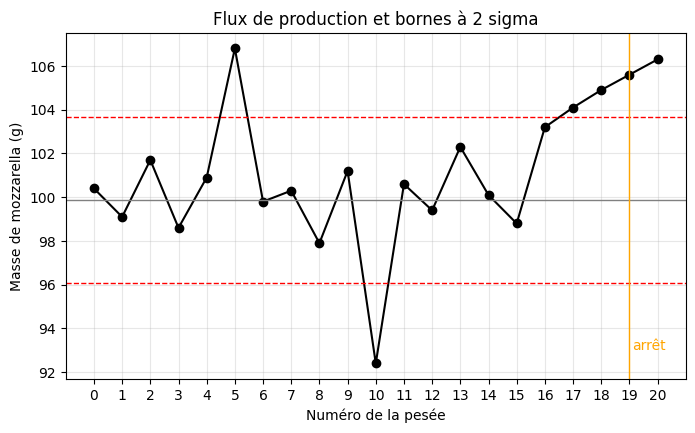

In [ ]:
# Cellule de visualisation uniquement : matplotlib ne sert qu'à tracer, pas à calculer.
import matplotlib.pyplot as plt

flux_temps_reel = [
    100.4, 99.1, 101.7, 98.6, 100.9, 106.8, 99.8, 100.3, 97.9, 101.2,
    92.4, 100.6, 99.4, 102.3, 100.1, 98.8, 103.2, 104.1, 104.9, 105.6,
    106.3,
]
MU = 99.888
SIGMA = 1.9007771743074244

indices = list(range(len(flux_temps_reel)))

plt.figure(figsize=(8, 4.5))
plt.plot(indices, flux_temps_reel, marker="o", color="black")
plt.axhline(MU, color="gray", linewidth=1)
plt.axhline(MU + 2 * SIGMA, color="red", linestyle="--", linewidth=1)
plt.axhline(MU - 2 * SIGMA, color="red", linestyle="--", linewidth=1)
plt.axvline(19, color="orange", linewidth=1)
plt.text(19.1, 93, "arrêt", color="orange")
plt.xticks(indices)
plt.xlabel("Numéro de la pesée")
plt.ylabel("Masse de mozzarella (g)")
plt.title("Flux de production et bornes à 2 sigma")
plt.grid(alpha=0.3)
plt.show()

**Lecture du graphique.** Les deux pics des pesées 5 et 10 sortent des bornes puis
redescendent aussitôt. À partir de la pesée 17, la courbe monte régulièrement et franchit la
borne haute sans revenir : la forme d'une dérive se distingue nettement de celle d'un pic.

## Bonus : l'effet de masquage

L'historique contient une pesée à 93,2 g, étonnamment basse pour une buse saine. On recalcule
la moyenne et l'écart-type sans elle, puis on compare son z-score dans les deux cas.

In [ ]:
historique_calibration = [
    102.5, 102.1, 96.9, 101.0, 98.9, 97.5, 100.3, 101.3, 104.1, 99.5,
    102.4, 93.2, 99.3, 99.9, 98.8, 101.9, 99.5, 101.9, 102.0, 98.0,
    99.6, 99.8, 99.6, 98.3, 98.4, 100.9, 98.2, 98.9, 101.6, 101.4,
    100.0, 97.6, 96.0, 100.2, 99.9, 101.9, 101.8, 99.1, 99.6, 100.0,
    100.2, 100.9, 102.7, 100.9, 100.6, 99.5, 98.5, 98.6, 98.7, 100.1,
]

def moyenne(valeurs):
    return sum(valeurs) / len(valeurs)

def ecart_type_estime(valeurs):
    m = moyenne(valeurs)
    total = 0
    for v in valeurs:
        total = total + (v - m) ** 2
    return (total / (len(valeurs) - 1)) ** 0.5

def z_score(valeur, mu, sigma):
    return (valeur - mu) / sigma

# Historique complet
mu_avec = moyenne(historique_calibration)
sigma_avec = ecart_type_estime(historique_calibration)

# Historique sans la pesée suspecte
sans_93 = []
for pesee in historique_calibration:
    if pesee != 93.2:
        sans_93.append(pesee)

mu_sans = moyenne(sans_93)
sigma_sans = ecart_type_estime(sans_93)

print(f"Avec 93,2 : mu = {mu_avec:.2f} g   sigma = {sigma_avec:.3f} g   z = {z_score(93.2, mu_avec, sigma_avec):+.2f}")
print(f"Sans 93,2 : mu = {mu_sans:.2f} g   sigma = {sigma_sans:.3f} g   z = {z_score(93.2, mu_sans, sigma_sans):+.2f}")

Avec 93,2 : mu = 99.89 g   sigma = 1.901 g   z = -3.52
Sans 93,2 : mu = 100.03 g   sigma = 1.655 g   z = -4.13


**Lecture du résultat.** Avec la pesée dans l'historique, son z-score vaut -3,52. Sans elle,
il vaut -4,13. La valeur extrême gonfle l'écart-type qui sert à la juger, donc elle atténue son
propre écart : c'est l'effet de masquage. Un historique de calibration doit donc être constitué
sur une machine dont on a vérifié l'état, et nettoyé de ses valeurs douteuses.